# Day 1 — Descriptive Statistics: The Mean Lied to Me

**#30DaysOfMachineLearning**

## Business problem

StreamFlix (fictional streaming platform) has 1,200 titles live on the platform.
The Content team ran a report and got worried: **"Our average content rating is only 6.3/10 — is our catalogue actually bad?"**

Before recommending the team pull titles or renegotiate licensing deals, we need to check
whether the **mean** is even the right number to trust here, or whether it's being distorted
by a small number of very low-rated titles.

**Goal of this notebook:**
1. Compute mean, median, mode, variance and standard deviation of `avg_rating`.
2. Visualize the distribution to see *why* the mean and median disagree.
3. Break the picture down by genre to find where quality is genuinely inconsistent.
4. Turn the stats into a business recommendation.


## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from stats_utils import (
    central_tendency,
    dispersion,
    skew_report,
    summarize,
    plot_distribution,
    group_dispersion,
)

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")


## 2. Load the data

Dataset generated by `generate_dataset.py` — a synthetic but realistic catalogue of 1,200 titles with a deliberate long tail of low-rated content (mirrors real streaming-platform rating distributions).

In [2]:
df = pd.read_csv("data/streaming_ratings.csv")
print(df.shape)
df.head()


(1200, 6)


,title_id,genre,release_year,runtime_minutes,n_reviews,avg_rating
0,SF100000,Sci-Fi,2017,58,41366,6.7
1,SF100001,Horror,2007,152,19667,5.1
2,SF100002,Sci-Fi,2007,84,28653,6.9
3,SF100003,Action,2018,76,4849,6.4
4,SF100004,Reality TV,2013,137,15900,5.9


In [3]:
# NOTE: df.describe(numeric_only=True) raises a TypeError on pandas 3.x
# (the numeric_only kwarg was dropped). Select numeric columns first instead.
df.select_dtypes(include="number").describe()


,release_year,runtime_minutes,n_reviews,avg_rating
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2014.965833,100.866667,24060.595833,6.324583
std,5.950280,45.843486,14533.033869,1.704785
min,2005.000000,20.000000,70.000000,1.000000
25%,2010.000000,61.000000,11504.500000,5.875000
50%,2015.000000,104.000000,23236.500000,6.800000
75%,2020.000000,140.000000,36430.000000,7.400000
max,2025.000000,179.000000,49975.000000,9.100000


## 3. Central tendency — mean, median, mode

This is the number the Content team already has (the mean). Let's put it next to median and mode before drawing any conclusions.

In [4]:
ct = central_tendency(df["avg_rating"])
ct


mean      6.324583
median    6.800000
mode      7.100000

In [5]:
print(skew_report(df["avg_rating"]))


mean=6.32, median=6.80, skewness=-1.38 -> distribution looks left-skewed (a low tail is pulling the mean down). (mean - median = -0.48)


**Reading this:** the median sits noticeably above the mean. That's the signature of a *left-skewed* distribution — a cluster of low scores is pulling the average down, even though most titles individually score higher than the average suggests.

## 4. Visualize the distribution

Seeing *why* mean ≠ median matters more than the numbers alone.

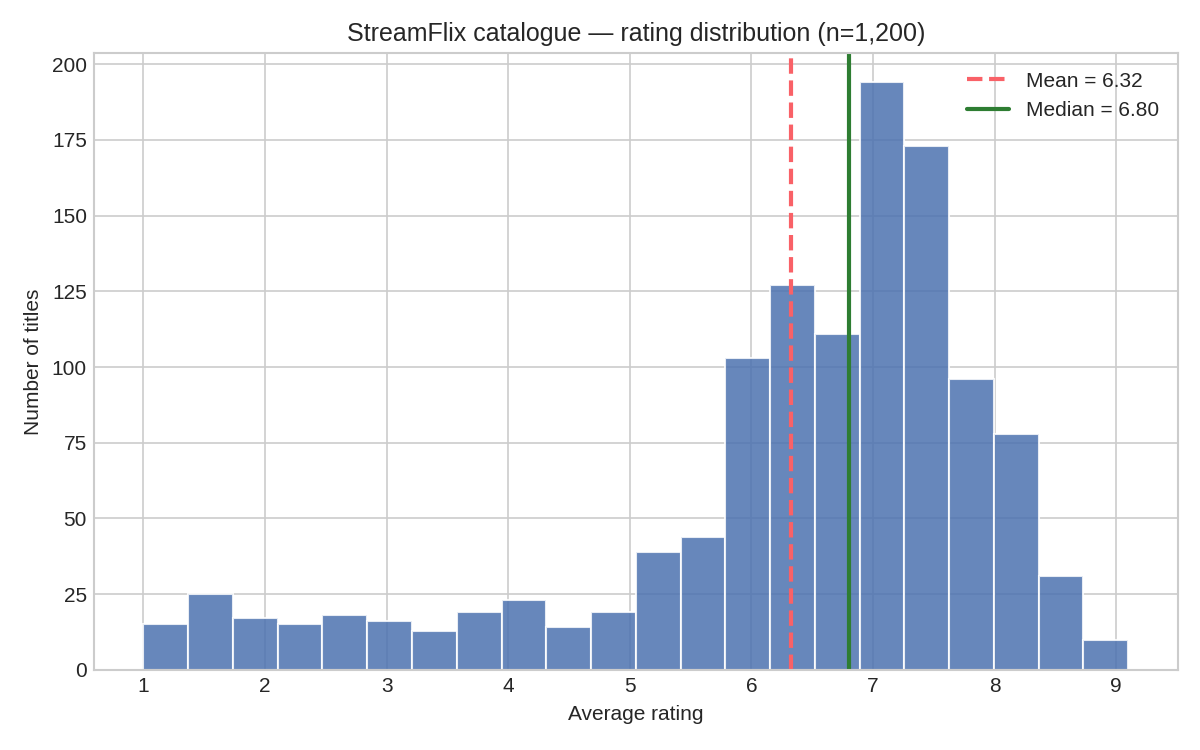

In [6]:
ax = plot_distribution(df["avg_rating"], title="StreamFlix catalogue — rating distribution (n=1,200)", bins=22)
plt.xlabel("Average rating")
plt.tight_layout()
plt.savefig("rating_distribution.png", dpi=150)
plt.show()


## 5. Spread — variance & standard deviation

Central tendency alone doesn't tell the team *how consistent* quality is. Two catalogues can share a mean and still tell very different stories.

In [7]:
d = dispersion(df["avg_rating"])
d


variance    2.906293
std_dev     1.704785
range       8.100000
iqr         1.525000

## 6. Where is the inconsistency coming from? (segment by genre)

Aggregate stats can hide the real story. Breaking down by genre shows *where* to focus.

In [8]:
genre_stats = group_dispersion(df, group_col="genre", value_col="avg_rating")
genre_stats


,mean,median,std_dev,count
genre,,,,
Horror,5.324044,5.8,1.860808,183
Action,6.262205,6.8,1.657447,127
Sci-Fi,6.573529,6.9,1.575386,170
Reality TV,4.848252,5.2,1.526012,143
Comedy,6.540984,6.8,1.436767,183
Romance,6.501626,6.8,1.388889,123
Drama,7.138194,7.3,1.140604,144
Documentary,7.751969,7.8,0.839109,127


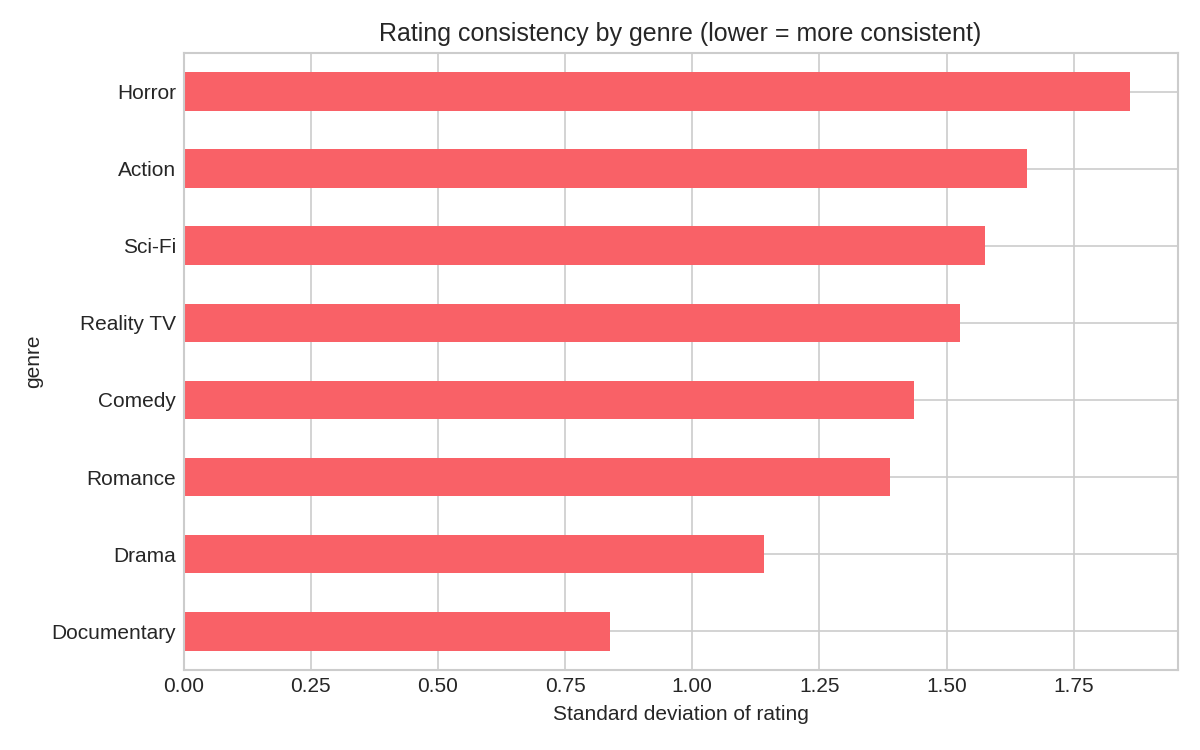

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
genre_stats["std_dev"].sort_values().plot(kind="barh", color="#F96167", ax=ax)
ax.set_xlabel("Standard deviation of rating")
ax.set_title("Rating consistency by genre (lower = more consistent)")
plt.tight_layout()
plt.savefig("genre_std_dev.png", dpi=150)
plt.show()


## 7. Business takeaways

- **Don't lead with the mean on skewed data.** The median (typical title) tells a materially more optimistic and more accurate story than the mean the Content team started with.
- **The real problem is a *tail*, not the whole catalogue.** A minority of very low-rated titles is dragging the average down — the fix is targeted (audit/retire the worst-performing titles) rather than platform-wide.
- **Genre breakdown points to where to act.** The genres with the highest standard deviation are the ones with the least consistent quality — that's where a content audit will have the most impact.
- **Recommendation:** report median rating (not mean) as the primary catalogue-health KPI going forward, and stand up a quarterly review of the bottom-decile titles by rating.


---
*Day 1 of #30DaysOfMachineLearning — Descriptive Statistics. Code: `stats_utils.py` · Data: `data/streaming_ratings.csv`*